<a href="https://colab.research.google.com/github/andrealopez47/goatdevice_evaluation/blob/main/movement_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimated baseline: 9.803 m/s²
Activity threshold: 0.35

===== ACTIVITY SUMMARY =====

state
ACTIVE      3972
INACTIVE    3128
Name: count, dtype: int64

===== ACTIVITY WINDOWS =====

         state         start           end  duration_s
0       ACTIVE  08:54:03.000  08:54:03.100         0.1
1     INACTIVE  08:54:03.200  08:54:03.200         0.0
2       ACTIVE  08:54:03.300  08:54:03.800         0.5
3     INACTIVE  08:54:03.900  08:54:04.000         0.1
4       ACTIVE  08:54:04.100  08:54:04.400         0.3
...        ...           ...           ...         ...
1441  INACTIVE  09:05:45.000  09:05:45.000         0.0
1442    ACTIVE  09:05:45.100  09:05:45.200         0.1
1443  INACTIVE  09:05:45.300  09:05:50.000         4.7
1444    ACTIVE  09:05:50.100  09:05:50.100         0.0
1445  INACTIVE  09:05:50.200  09:05:52.900         2.7

[1446 rows x 4 columns]

Generated file:
/content/activity_windows.csv


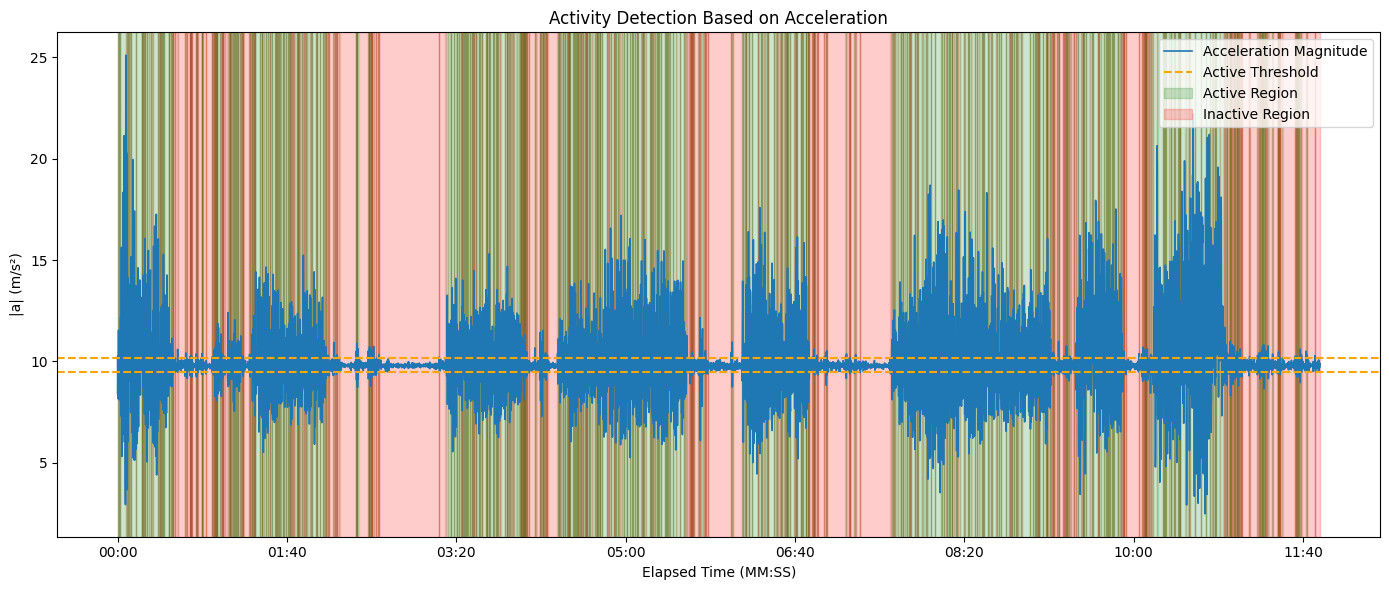

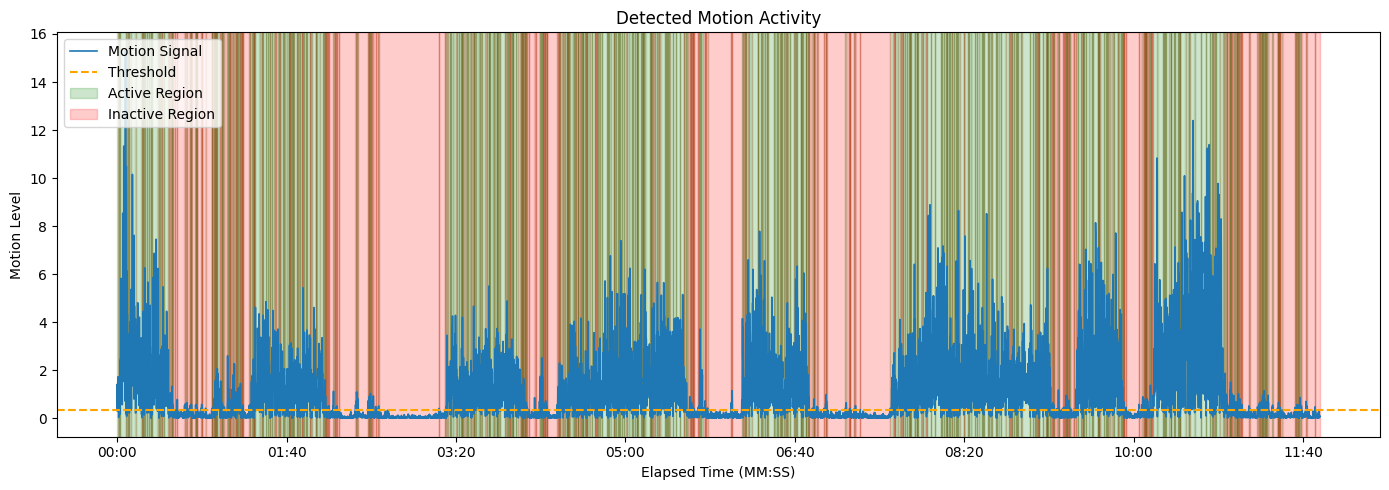

In [7]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches


# Function to format elapsed seconds into MM:SS
def format_elapsed_time(x, pos):
    minutes = int(x // 60)
    seconds = int(x % 60)
    return f"{minutes:02d}:{seconds:02d}"


# ==========================================q
# LOAD CSV FILE
# ==========================================

# Upload this file to Colab:
# tiempos_corregidos.csv

file_path = "/content/sample_data/tiempos_corregidos.csv"

# CSV separator
# Change sep if needed

df = pd.read_csv(file_path, sep=",")


# ==========================================
# RENAME TIME COLUMN
# ==========================================

# Rename for simplicity
# Change this if your column has another name

df = df.rename(columns={
    "time_corrected": "time"
})


# ==========================================
# CONVERT TIME COLUMN
# ==========================================

# Convert time with milliseconds

df["time_dt"] = pd.to_datetime(
    df["time"],
    errors="coerce"
)


# ==========================================
# REMOVE INVALID ROWS
# ==========================================

df = df.dropna(subset=["time_dt"])

# Calculate elapsed time in seconds from the start of the recording
min_time = df["time_dt"].min()
df["elapsed_seconds"] = (df["time_dt"] - min_time).dt.total_seconds()


# ==========================================
# CONVERT ACCELERATION TO NUMERIC
# ==========================================

for col in ["ax", "ay", "az"]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ==========================================
# REMOVE INVALID VALUES
# ==========================================

df = df.dropna(subset=["ax", "ay", "az"])


# ==========================================
# ACCELERATION MAGNITUDE
# ==========================================

# |a| = sqrt(ax² + ay² + az²)

df["mag"] = np.sqrt(
    df["ax"]**2 +
    df["ay"]**2 +
    df["az"]**2
)


# ==========================================
# BASELINE ESTIMATION
# ==========================================

# Estimate gravity baseline automatically
# using the median acceleration

baseline = df["mag"].median()

print(f"Estimated baseline: {baseline:.3f} m/s²")


# ==========================================
# MOTION SIGNAL
# ==========================================

# Difference from baseline

df["motion"] = np.abs(
    df["mag"] - baseline
)


# ==========================================q
# ACTIVITY THRESHOLD
# ==========================================

# Adjust this value if needed
# Lower threshold = more sensitive
# Higher threshold = less sensitive

threshold = 0.35

print(f"Activity threshold: {threshold:.2f}")


# ==========================================
# ACTIVITY DETECTION
# ==========================================

# Active if motion exceeds threshold

df["state"] = np.where(
    df["motion"] > threshold,
    "ACTIVE",
    "INACTIVE"
)


# ==========================================
# ACTIVITY SUMMARY
# ==========================================

print("\n===== ACTIVITY SUMMARY =====\n")

print(
    df["state"].value_counts()
)


# ==========================================
# CREATE ACTIVITY WINDOWS
# ==========================================

# Detect state changes

df["change"] = (
    df["state"] != df["state"].shift()
).cumsum()

windows = []

for _, group in df.groupby("change"):

    start_time = group["time_dt"].iloc[0]
    end_time = group["time_dt"].iloc[-1]

    state = group["state"].iloc[0]

    duration = (
        end_time - start_time
    ).total_seconds()

    windows.append({
        "state": state,
        "start": start_time.strftime("%H:%M:%S.%f")[:-3],
        "end": end_time.strftime("%H:%M:%S.%f")[:-3],
        "duration_s": round(duration, 3)
    })


# ==========================================
# WINDOWS TABLE
# ==========================================

windows_df = pd.DataFrame(windows)

print("\n===== ACTIVITY WINDOWS =====\n")

print(windows_df)


# ==========================================
# EXPORT WINDOWS
# ==========================================

windows_df.to_csv(
    "/content/activity_windows.csv",
    index=False
)

print("\nGenerated file:")
print("/content/activity_windows.csv")


# ==========================================
# PLOT ACCELERATION MAGNITUDE
# ==========================================

plt.figure(figsize=(14, 6))


# Main signal
plt.plot(
    df["elapsed_seconds"],
    df["mag"],
    linewidth=1.2,
    label="Acceleration Magnitude"
)


# Threshold lines
plt.axhline(
    baseline + threshold,
    linestyle="--",
    linewidth=1.5,
    color='orange',
    label="Active Threshold"
)

plt.axhline(
    baseline - threshold,
    linestyle="--",
    linewidth=1.5,
    color='orange'
)


# ==========================================q
# HIGHLIGHT ACTIVE & INACTIVE REGIONS
# ==========================================

for _, group in df.groupby("change"):

    state = group["state"].iloc[0]

    start_elapsed = group["elapsed_seconds"].iloc[0]
    end_elapsed = group["elapsed_seconds"].iloc[-1]

    if state == "ACTIVE":

        plt.axvspan(
            start_elapsed,
            end_elapsed,
            alpha=0.2,
            color='green'
        )
    else:
        plt.axvspan(
            start_elapsed,
            end_elapsed,
            alpha=0.2,
            color='red'
        )


# ==========================================q
# AXIS FORMAT
# ==========================================

ax = plt.gca()

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(format_elapsed_time)
)

# Removed plt.xticks(rotation=45)


# ==========================================
# LABELS
# ==========================================

plt.xlabel("Elapsed Time (MM:SS)")

plt.ylabel("|a| (m/s²)")

plt.title("Activity Detection Based on Acceleration")

# Create custom legend handles for the shaded regions
active_patch = mpatches.Patch(color='green', alpha=0.2, label='Active Region')
inactive_patch = mpatches.Patch(color='red', alpha=0.2, label='Inactive Region')

# Get existing handles and labels from the plot
handles, labels = ax.get_legend_handles_labels()

# Add the custom patches to the handles and labels
handles.extend([active_patch, inactive_patch])

# Create the legend with all handles and labels
plt.legend(handles=handles)

plt.tight_layout()

plt.show()


# ==========================================
# SECOND PLOT: MOTION SIGNAL
# ==========================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["elapsed_seconds"],
    df["motion"],
    linewidth=1.2,
    label="Motion Signal"
)

plt.axhline(
    threshold,
    linestyle="--",
    linewidth=1.5,
    color='orange',
    label="Threshold"
)


# Highlight active regions
for _, group in df.groupby("change"):

    state = group["state"].iloc[0]

    start_elapsed = group["elapsed_seconds"].iloc[0]
    end_elapsed = group["elapsed_seconds"].iloc[-1]

    if state == "ACTIVE":

        plt.axvspan(
            start_elapsed,
            end_elapsed,
            alpha=0.2,
            color='green'
        )
    else:
        plt.axvspan(
            start_elapsed,
            end_elapsed,
            alpha=0.2,
            color='red'
        )


# Axis formatting
ax = plt.gca()

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(format_elapsed_time)
)

# Removed plt.xticks(rotation=45)


# Labels
plt.xlabel("Elapsed Time (MM:SS)")

plt.ylabel("Motion Level")

plt.title("Detected Motion Activity")

# Create custom legend handles for the shaded regions
active_patch_motion = mpatches.Patch(color='green', alpha=0.2, label='Active Region')
inactive_patch_motion = mpatches.Patch(color='red', alpha=0.2, label='Inactive Region')

# Get existing handles and labels from the plot
handles_motion, labels_motion = ax.get_legend_handles_labels()

# Add the custom patches to the handles and labels
handles_motion.extend([active_patch_motion, inactive_patch_motion])

# Create the legend with all handles and labels
plt.legend(handles=handles_motion)

plt.tight_layout()

plt.show()